In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
project_dir = '/content/drive/MyDrive/HousePricePrediction_AasthaMalviya'
charts_dir = os.path.join(project_dir, 'charts')

os.makedirs(charts_dir, exist_ok=True)
print(f"Project structure ready at: {project_dir}")

Project structure ready at: /content/drive/MyDrive/HousePricePrediction_AasthaMalviya


**Importing Dataset**

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.63k/4.63k [00:00<00:00, 7.26MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


In [4]:
import shutil
import os

data_dir = os.path.join(project_dir, 'data')
os.makedirs(data_dir, exist_ok=True)


source_dataset_path = path
destination_dataset_path = os.path.join(data_dir, os.path.basename(source_dataset_path))

shutil.copytree(source_dataset_path, destination_dataset_path)

print(f"Dataset moved to: {destination_dataset_path}")

Dataset moved to: /content/drive/MyDrive/HousePricePrediction_AasthaMalviya/data/1


**Installing Essential Libraries**

In [9]:

!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")

project_dir = '/content/drive/MyDrive/HousePricePrediction_AasthaMalviya'
charts_dir = os.path.join(project_dir, 'charts')
os.makedirs(charts_dir, exist_ok=True)

print("Environment ready!")

Environment ready!


In [10]:
# --- TASK 1: DATA LOADING & EXPLORATION ---

# 1. Load the CSV
df = pd.read_csv('/content/drive/MyDrive/HousePricePrediction_AasthaMalviya/data/Housingdata/Housing.csv')

# 2. Display the first 10 rows
display("First 10 Rows:", df.head(10))

# 3. Check rows and columns
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# 4. Identify Target and Features
target_col = 'price'
features = [col for col in df.columns if col != target_col]
print(f"\nTarget Variable: {target_col}")
print(f"Features: {features}")

# 5. Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

'First 10 Rows:'

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Shape: 545 rows and 13 columns

Target Variable: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values per Column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [11]:
# --- TASK 2: DATA CLEANING & ENGINEERING ---

# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Handle missing values (dropping any rows with NAs for clean baseline)
df = df.dropna()

# 3.
# Assuming standard categorical columns exist
# Aggregate basic yes/no amenities into a single "Premium Score"
amenity_cols = ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
existing_amenities = [col for col in amenity_cols if col in df.columns]

# Convert 'yes'/'no' to 1/0 for these specific columns first
for col in existing_amenities:
    df[col] = df[col].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)

# Create the engineered feature
if existing_amenities:
    df['premium_amenities_score'] = df[existing_amenities].sum(axis=1)

# 4. Convert remaining categorical columns using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print("Data Cleaning and Encoding Complete. Current shape:", df_encoded.shape)

Data Cleaning and Encoding Complete. Current shape: (545, 15)


In [13]:
# --- TASK 3: MODEL BUILDING ---

# 1. Spliting data (80/20)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to evaluate models
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2}

# 2. Train and Evaluate Linear Regression
lr_model = LinearRegression()
lr_metrics = evaluate_model(lr_model, "Linear Regression")

# 3. Train and Evaluate Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_metrics = evaluate_model(rf_model, "Random Forest")

# 4. Comparing Performance
results_df = pd.DataFrame([lr_metrics, rf_metrics])
display("Model Comparison:", results_df)

'Model Comparison:'

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.001733e+06,1.383449e+06,0.621347


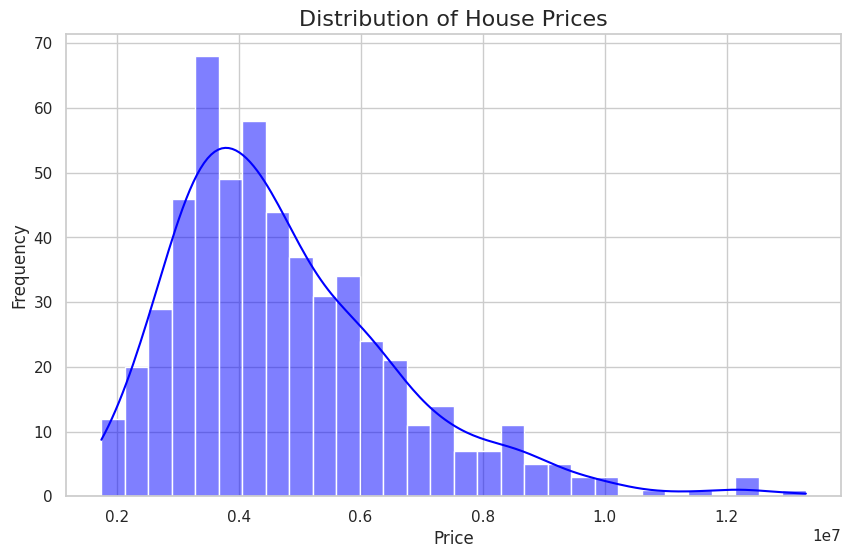

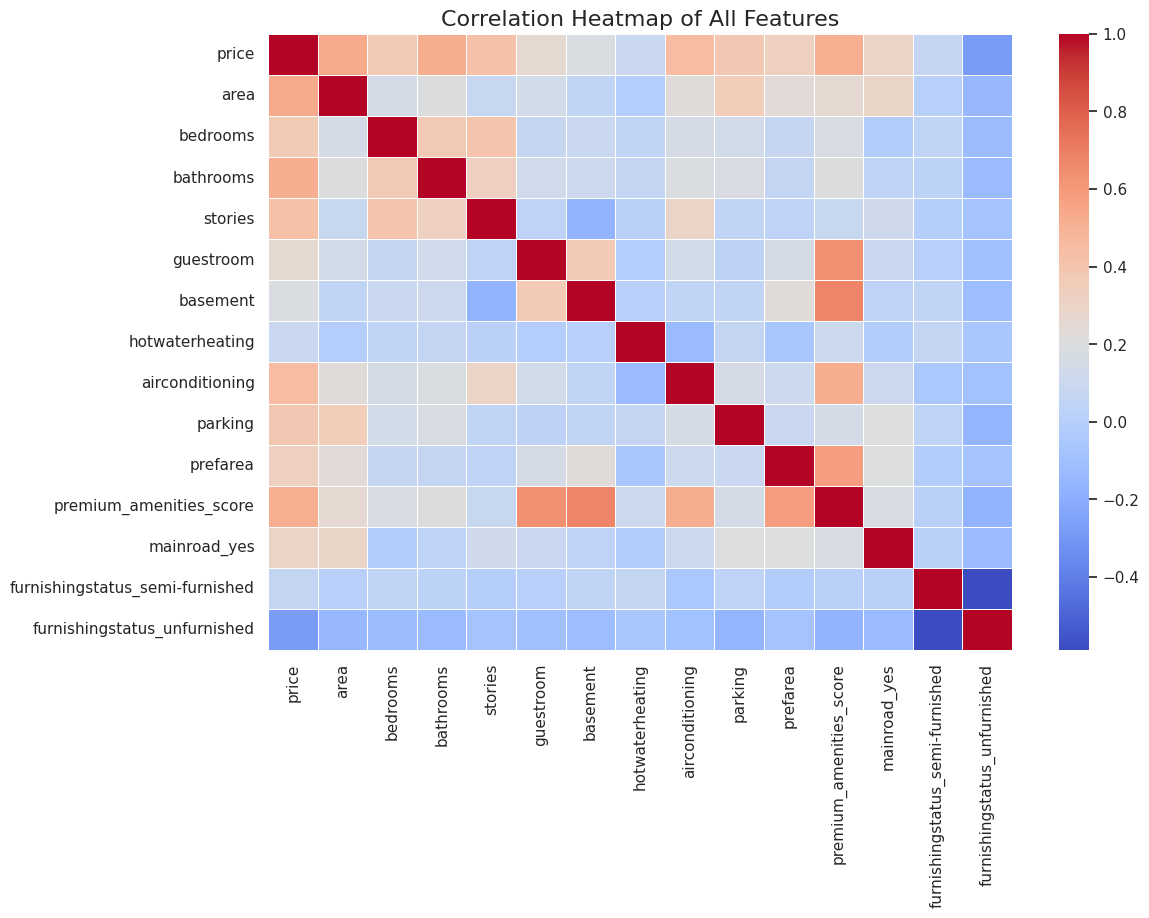

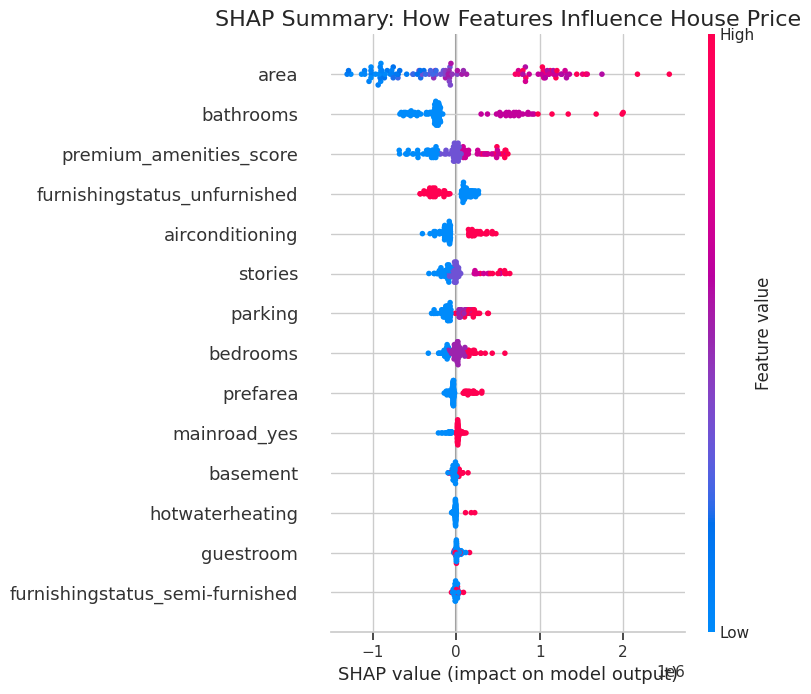

All charts successfully saved to /content/drive/MyDrive/HousePricePrediction_AasthaMalviya/charts


In [14]:
# --- TASK 4: VISUALIZATION ---

# Chart 1: Histogram showing distribution of house prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig(f'{charts_dir}/Chart1_Price_Distribution.png', bbox_inches='tight')
plt.show()

# Chart 2: Correlation heatmap showing feature relationships
plt.figure(figsize=(12, 8))
# Calculating correlation matrix
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.savefig(f'{charts_dir}/Chart2_Correlation_Heatmap.png', bbox_inches='tight')
plt.show()

# Chart 3: SHAP Feature Importance
# This proves mathematically WHICH features drive the price up or down
plt.figure(figsize=(10, 6))
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.title('SHAP Summary: How Features Influence House Price', fontsize=16)
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig(f'{charts_dir}/Chart3_SHAP_Feature_Importance.png', bbox_inches='tight')
plt.show()

print(f"All charts successfully saved to {charts_dir}")

## TASK 5: Insights & Summary

Based on the analysis:

*   **Influential Features:** The SHAP summary plot (Chart 3) clearly indicates that `area` is by far the most influential feature driving house prices, followed by `bathrooms` and `premium_amenities_score` (which aggregates features like guestroom, basement, air conditioning, etc.). `furnishingstatus_unfurnished` also has a significant negative impact.

*   **Model Accuracy:** The Random Forest model achieved an R2 score of approximately 0.62. This means that about 62% of the variance in house prices can be explained by the features included in our model. While not perfect, it's a reasonably good starting point, suggesting the model captures a significant portion of the price determinants. The Mean Absolute Error (MAE) of around 1 million suggests that, on average, our predictions were off by about 1 million units of currency from the actual house prices.

*   **Surprising Data Aspects:** It was interesting to observe the non-linear relationship in the price distribution, with a noticeable skew towards lower-priced houses, which is common in real estate but visually evident in Chart 1. Also, the strong positive correlation between `area`, `bathrooms`, and `price` (from Chart 2) was expected, but the `premium_amenities_score` emerging as a top driver via SHAP suggests that bundled amenities are highly valued.

*   **Business Recommendation:** For a real estate business, focus marketing and development efforts on properties with larger areas and more bathrooms, as these are the primary drivers of higher prices. Additionally, emphasizing and potentially upgrading properties to include premium amenities (guestroom, basement, air conditioning, etc.) can significantly boost property value. For unfurnished properties, consider offering staging or furnishing options to attract a wider range of buyers and potentially mitigate the negative impact of the 'unfurnished' status.